#Prepare Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

base_path = "/content/drive/MyDrive/Crime_DataSet/india_crime"

for file in os.listdir(base_path):
    print(file)

crime
10_Property_stolen_and_recovered.csv
29_Period_of_trials_by_courts.csv
20_Victims_of_rape.csv
30_Auto_theft.csv
28_Trial_of_violent_crimes_by_courts.csv
25_Complaints_against_police.csv
33_CH_not_murder_victim_age_sex.csv
32_Murder_victim_age_sex.csv
35_Human_rights_violation_by_police.csv
31_Serious_fraud.csv
40_01_Custodial_death_person_remanded.csv
36_Police_housing.csv
39_Specific_purpose_of_kidnapping_and_abduction.csv
40_02_Custodial_death_person_not_remanded.csv
40_03_Custodial_death_during_production.csv
40_04_Custodial_death_during_hospitalization_or_treatment.csv
43_Arrests_under_crime_against_women.csv
42_Cases_under_crime_against_women.csv
40_05_Custodial_death_others.csv


In [ ]:
#choose one with file "10_Property"

import pandas as pd

file_path = base_path + "/10_Property_stolen_and_recovered.csv"

df = pd.read_csv(file_path)

df.head()

,Area_Name,Year,Group_Name,Sub_Group_Name,Cases_Property_Recovered,Cases_Property_Stolen,Value_of_Property_Recovered,Value_of_Property_Stolen
0,Andaman & Nicobar Islands,2001,Burglary - Property,3. Burglary,27,64,755858,1321961
1,Andhra Pradesh,2001,Burglary - Property,3. Burglary,3321,7134,51483437,147019348
2,Arunachal Pradesh,2001,Burglary - Property,3. Burglary,66,248,825115,4931904
3,Assam,2001,Burglary - Property,3. Burglary,539,2423,3722850,21466955
4,Bihar,2001,Burglary - Property,3. Burglary,367,3231,2327135,17023937


In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2449 entries, 0 to 2448
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Area_Name                    2449 non-null   object
 1   Year                         2449 non-null   int64 
 2   Group_Name                   2449 non-null   object
 3   Sub_Group_Name               2449 non-null   object
 4   Cases_Property_Recovered     2449 non-null   int64 
 5   Cases_Property_Stolen        2449 non-null   int64 
 6   Value_of_Property_Recovered  2449 non-null   int64 
 7   Value_of_Property_Stolen     2449 non-null   int64 
dtypes: int64(5), object(3)
memory usage: 153.2+ KB


,0
Area_Name,0
Year,0
Group_Name,0
Sub_Group_Name,0
Cases_Property_Recovered,0
Cases_Property_Stolen,0
Value_of_Property_Recovered,0
Value_of_Property_Stolen,0


In [ ]:
df_state = df.groupby("Area_Name")[[
    "Cases_Property_Stolen",
    "Value_of_Property_Stolen",
    "Cases_Property_Recovered",
    "Value_of_Property_Recovered"
]].sum().reset_index()

df_state.head()

,Area_Name,Cases_Property_Stolen,Value_of_Property_Stolen,Cases_Property_Recovered,Value_of_Property_Recovered
0,Andaman & Nicobar Islands,3662,646746834,1516,53629194
1,Andhra Pradesh,642822,18762833176,332510,8320971694
2,Arunachal Pradesh,16632,1895885402,6048,646754238
3,Assam,245560,5814831574,54784,1521007674
4,Bihar,411840,7549162134,63876,1098784766


In [ ]:
features = df_state[[
    "Cases_Property_Stolen",
    "Value_of_Property_Stolen",
    "Cases_Property_Recovered",
    "Value_of_Property_Recovered"
]]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

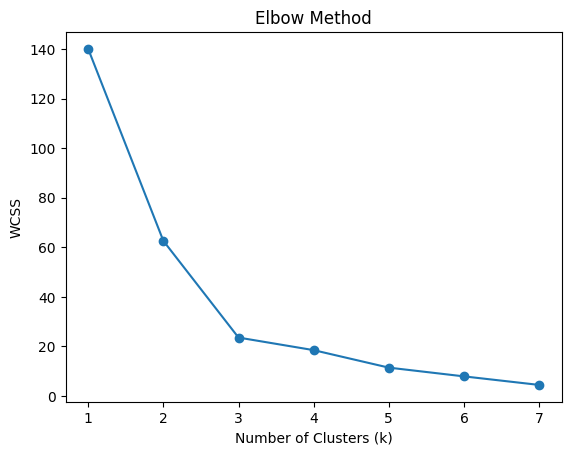

In [ ]:
wcss = []

for k in range(1, 8):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1,8), wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.6217018982792902


In [ ]:
df_state["Cluster"] = labels
df_state.head()

,Area_Name,Cases_Property_Stolen,Value_of_Property_Stolen,Cases_Property_Recovered,Value_of_Property_Recovered,Cluster
0,Andaman & Nicobar Islands,3662,646746834,1516,53629194,0
1,Andhra Pradesh,642822,18762833176,332510,8320971694,1
2,Arunachal Pradesh,16632,1895885402,6048,646754238,0
3,Assam,245560,5814831574,54784,1521007674,0
4,Bihar,411840,7549162134,63876,1098784766,0


In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

df_state = df.groupby("Area_Name")[numeric_cols].sum().reset_index()

In [ ]:
df_state = df.groupby("Area_Name", as_index=False).agg({
    "Cases_Property_Stolen": "sum",
    "Value_of_Property_Stolen": "sum",
    "Cases_Property_Recovered": "sum",
    "Value_of_Property_Recovered": "sum"
})

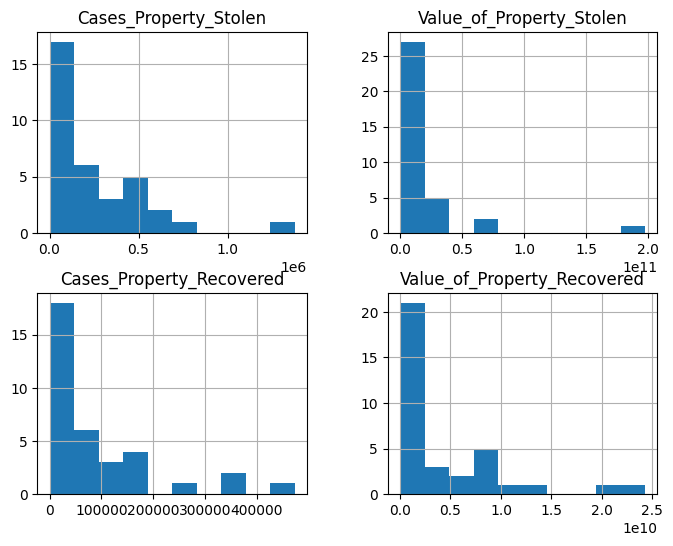

In [ ]:
features.hist(figsize=(8,6))
plt.show()

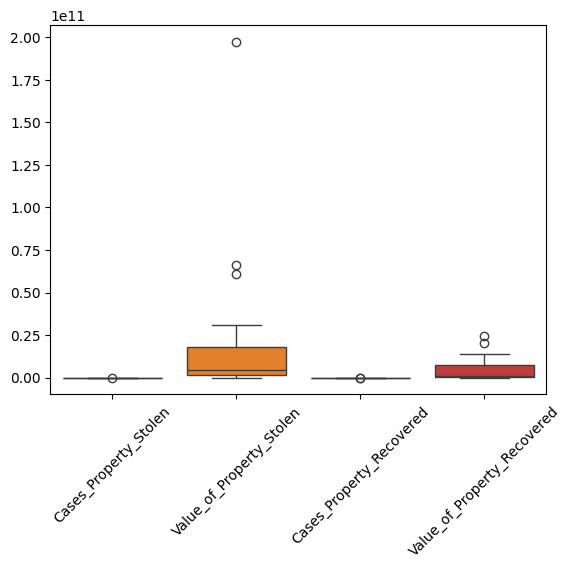

In [ ]:
sns.boxplot(data=features)
plt.xticks(rotation=45)
plt.show()

#Challenge with algorithm vs threshold

In [ ]:
from sklearn.preprocessing import StandardScaler

features = df_state[[
    "Cases_Property_Stolen",
    "Value_of_Property_Stolen",
    "Cases_Property_Recovered",
    "Value_of_Property_Recovered"
]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)


In [ ]:
#Kmean
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

sil_kmeans = silhouette_score(X_scaled, labels_kmeans)

print("KMeans Silhouette:", sil_kmeans)
print("Cluster counts:",
      {i: list(labels_kmeans).count(i) for i in set(labels_kmeans)})


KMeans Silhouette: 0.6217018982792902
Cluster counts: {np.int32(0): 25, np.int32(1): 9, np.int32(2): 1}


In [ ]:
#Hierarchical (Agglomerative)
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3)
labels_agg = agg.fit_predict(X_scaled)

sil_agg = silhouette_score(X_scaled, labels_agg)

print("Agglomerative Silhouette:", sil_agg)
print("Cluster counts:",
      {i: list(labels_agg).count(i) for i in set(labels_agg)})


Agglomerative Silhouette: 0.6113536262597028
Cluster counts: {np.int64(0): 10, np.int64(1): 24, np.int64(2): 1}


In [ ]:
#DBSCAN
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=3)
labels_db = dbscan.fit_predict(X_scaled)

# DBSCAN อาจมี label -1 (noise)
if len(set(labels_db)) > 1 and -1 not in set(labels_db):
    sil_db = silhouette_score(X_scaled, labels_db)
else:
    sil_db = "Not valid (noise only or single cluster)"

print("DBSCAN Silhouette:", sil_db)
print("Cluster counts:",
      {i: list(labels_db).count(i) for i in set(labels_db)})

DBSCAN Silhouette: Not valid (noise only or single cluster)
Cluster counts: {np.int64(0): 32, np.int64(-1): 3}


In [ ]:
#Threshold (ทำเอง)
import numpy as np

X_1d = X_scaled[:, 1]  # เลือก feature เดียว

threshold = np.mean(X_1d)

labels_threshold = (X_1d >= threshold).astype(int)

sil_threshold = silhouette_score(
    X_1d.reshape(-1,1),
    labels_threshold
)

print("Threshold Silhouette:", sil_threshold)
print("Cluster counts:",
      {i: list(labels_threshold).count(i)
       for i in set(labels_threshold)})


Threshold Silhouette: 0.5708705990210595
Cluster counts: {np.int64(0): 25, np.int64(1): 10}


In [ ]:
#Result all algorithm
results = {
    "KMeans": sil_kmeans,
    "Agglomerative": sil_agg,
    "DBSCAN": sil_db,
    "Threshold": sil_threshold
}

print("\n=== Comparison ===")
for k,v in results.items():
    print(k, ":", v)



=== Comparison ===
KMeans : 0.6217018982792902
Agglomerative : 0.6113536262597028
DBSCAN : Not valid (noise only or single cluster)
Threshold : 0.5708705990210595


#add Optimization to model

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    n_init=50,
    random_state=42
)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

best_k = None
best_score = -1
all_scores = {}

for k in range(2, 8):

    km = KMeans(
        n_clusters=k,
        n_init=50,          # เพิ่มความเสถียร
        random_state=42
    )

    labels = km.fit_predict(X_scaled)

    # เช็คว่ามีมากกว่า 1 cluster จริง
    if len(set(labels)) < 2:
        continue

    score = silhouette_score(X_scaled, labels)
    all_scores[k] = score

    if score > best_score:
        best_score = score
        best_k = k

print("All k scores:", all_scores)
print("Best k:", best_k)
print("Best Silhouette:", best_score)

All k scores: {2: np.float64(0.6152363420445974), 3: np.float64(0.6217018982792902), 4: np.float64(0.5509364319041109), 5: np.float64(0.5478345761570295), 6: np.float64(0.5721738383055943), 7: np.float64(0.6009941684604367)}
Best k: 3
Best Silhouette: 0.6217018982792902


In [ ]:
import numpy as np

# เลือก feature เดียวสำหรับ threshold
X_1d = X_scaled[:, 1]  # Value_of_Property_Stolen

best_t = None
best_score = -1
all_t_scores = {}

for t in np.linspace(X_1d.min(), X_1d.max(), 100):

    labels = (X_1d >= t).astype(int)

    # ต้องมี 2 cluster
    if len(set(labels)) < 2:
        continue

    # วัดบน 4D space (แฟร์!)
    score = silhouette_score(X_scaled, labels)
    all_t_scores[t] = score

    if score > best_score:
        best_score = score
        best_t = t

print("Best threshold:", best_t)
print("Best Silhouette (4D):", best_score)

Best threshold: 1.4591668836295246
Best Silhouette (4D): 0.7644997007903849


In [ ]:
features.corr()

,Cases_Property_Stolen,Value_of_Property_Stolen,Cases_Property_Recovered,Value_of_Property_Recovered
Cases_Property_Stolen,1.000000,0.847856,0.927583,0.897429
Value_of_Property_Stolen,0.847856,1.000000,0.747591,0.728736
Cases_Property_Recovered,0.927583,0.747591,1.000000,0.869221
Value_of_Property_Recovered,0.897429,0.728736,0.869221,1.000000


In [ ]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_scaled)

print(pca.explained_variance_ratio_)

[0.87847218 0.0761989  0.03317054 0.01215839]


#plot graph

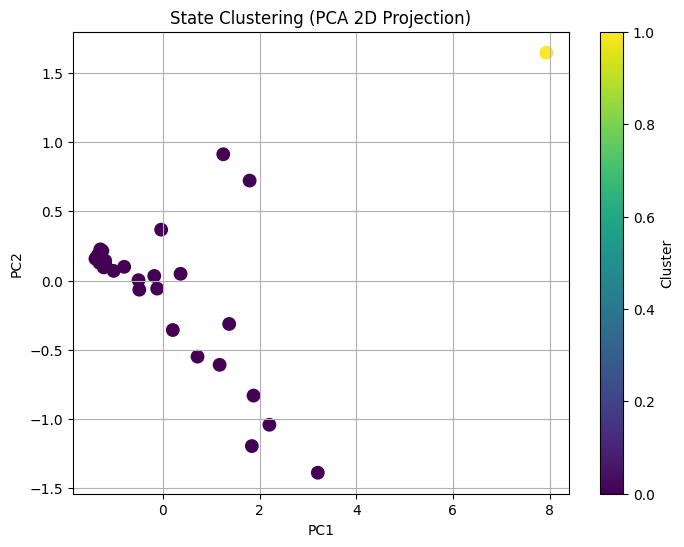

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ทำ PCA 2 มิติ
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1],
            c=labels, cmap='viridis', s=80)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("State Clustering (PCA 2D Projection)")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

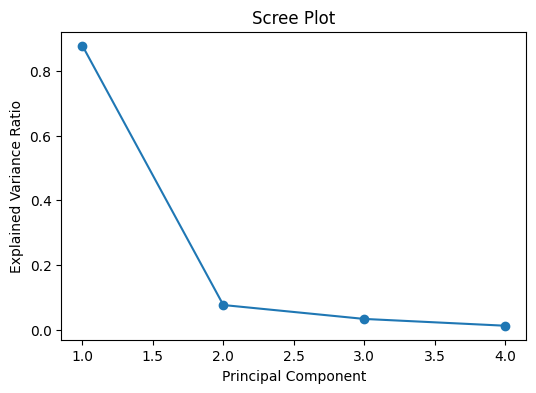

In [ ]:
pca_full = PCA()
pca_full.fit(X_scaled)

plt.figure(figsize=(6,4))
plt.plot(range(1,5), pca_full.explained_variance_ratio_,
         marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.show()

In [ ]:
print("PCA Loadings:")
print(pd.DataFrame(
    pca_full.components_.T,
    columns=["PC1","PC2","PC3","PC4"],
    index=features.columns
))

PCA Loadings:
                                  PC1       PC2       PC3       PC4
Cases_Property_Stolen        0.523398 -0.026640 -0.150040  0.838351
Value_of_Property_Stolen     0.471325  0.839969  0.099731 -0.249717
Cases_Property_Recovered     0.505583 -0.337597 -0.658132 -0.444159
Value_of_Property_Recovered  0.498291 -0.423993  0.731029 -0.193732


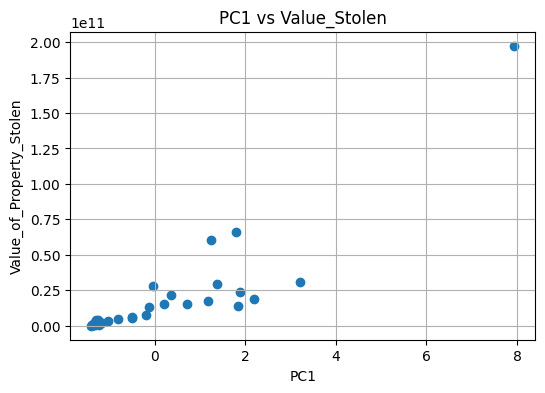

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], features["Value_of_Property_Stolen"])
plt.xlabel("PC1")
plt.ylabel("Value_of_Property_Stolen")
plt.title("PC1 vs Value_Stolen")
plt.grid(True)
plt.show()

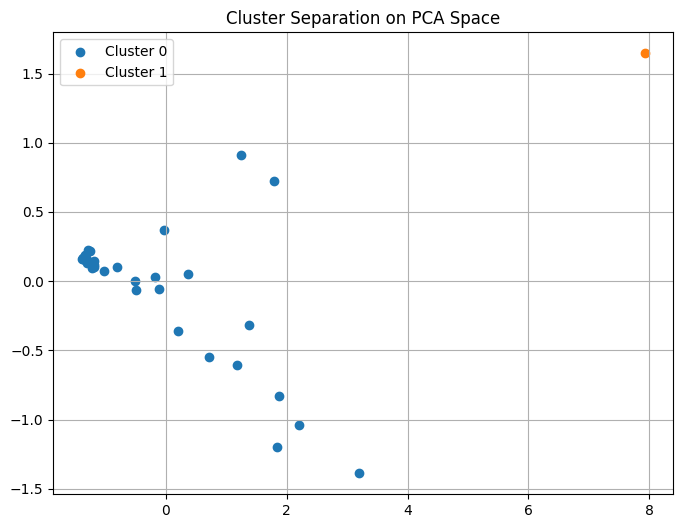

In [ ]:
plt.figure(figsize=(8,6))

for c in sorted(set(labels)):
    idx = labels == c
    plt.scatter(X_pca[idx,0], X_pca[idx,1], label=f"Cluster {c}")

plt.legend()
plt.title("Cluster Separation on PCA Space")
plt.grid(True)
plt.show()

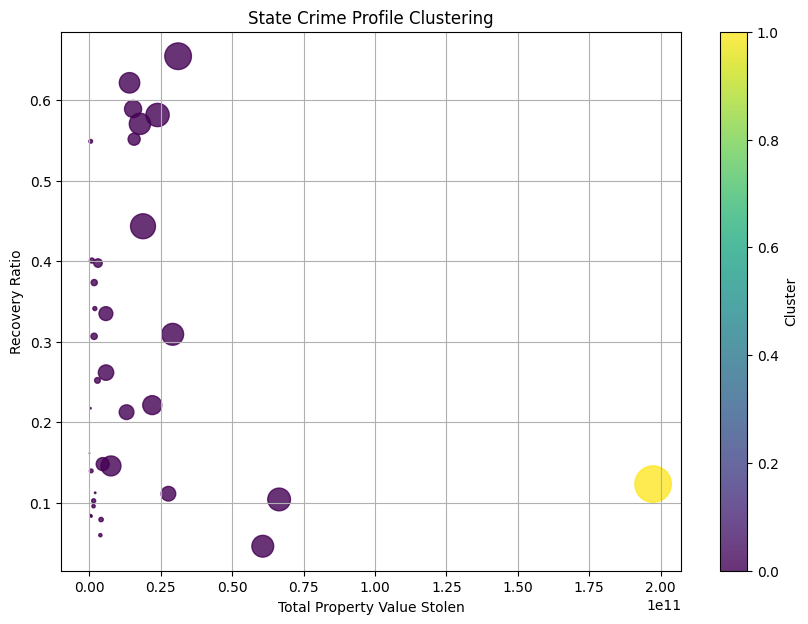

In [ ]:
import matplotlib.pyplot as plt

# Re-add the 'Cluster' column to df_state after its last redefinition
df_state["Cluster"] = labels

# สร้าง ratio ก่อน
df_state["Recovery_Ratio"] = (
    df_state["Value_of_Property_Recovered"] /
    df_state["Value_of_Property_Stolen"]
)

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    df_state["Value_of_Property_Stolen"],
    df_state["Recovery_Ratio"],
    c=df_state["Cluster"],
    cmap="viridis",
    s=df_state["Cases_Property_Stolen"]/2000,  # ปรับขนาดจุด
    alpha=0.8
)

plt.xlabel("Total Property Value Stolen")
plt.ylabel("Recovery Ratio")
plt.title("State Crime Profile Clustering")

plt.colorbar(scatter, label="Cluster")

plt.grid(True)
plt.show()

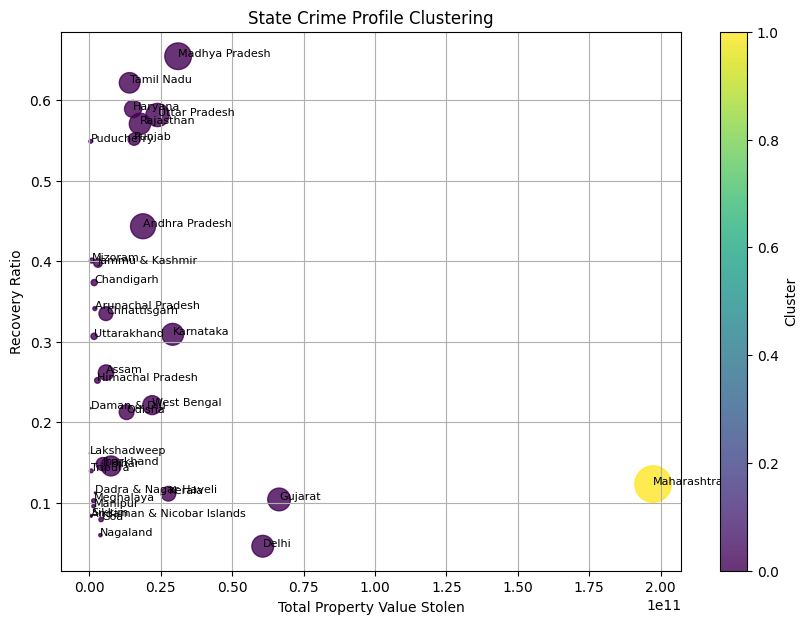

In [ ]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    df_state["Value_of_Property_Stolen"],
    df_state["Recovery_Ratio"],
    c=df_state["Cluster"],
    cmap="viridis",
    s=df_state["Cases_Property_Stolen"]/2000,
    alpha=0.8
)

for i, row in df_state.iterrows():
    plt.text(
        row["Value_of_Property_Stolen"],
        row["Recovery_Ratio"],
        row["Area_Name"],
        fontsize=8
    )

plt.xlabel("Total Property Value Stolen")
plt.ylabel("Recovery Ratio")
plt.title("State Crime Profile Clustering")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()


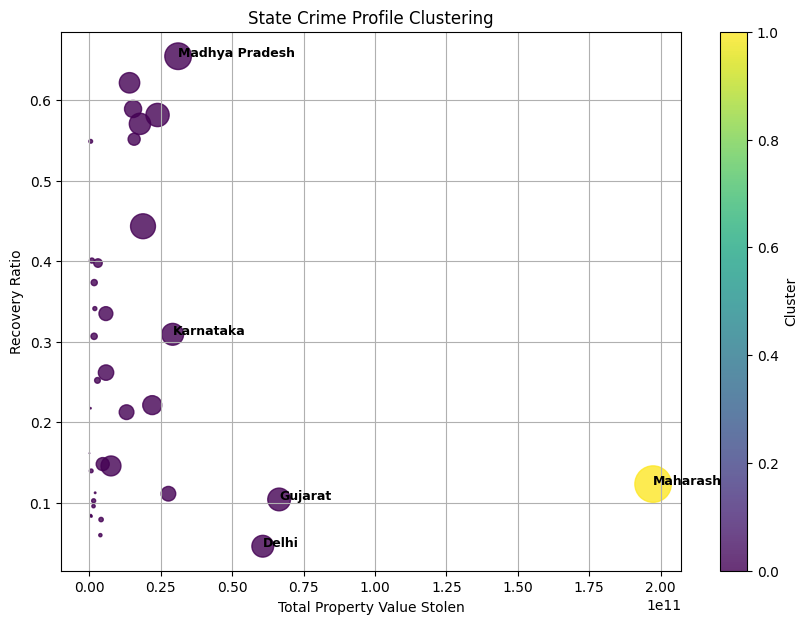

In [ ]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    df_state["Value_of_Property_Stolen"],
    df_state["Recovery_Ratio"],
    c=df_state["Cluster"],
    cmap="viridis",
    s=df_state["Cases_Property_Stolen"]/2000,
    alpha=0.8
)

# เลือก top 5 value
top_states = df_state.nlargest(5, "Value_of_Property_Stolen")

for i, row in top_states.iterrows():
    plt.text(
        row["Value_of_Property_Stolen"],
        row["Recovery_Ratio"],
        row["Area_Name"],
        fontsize=9,
        fontweight="bold"
    )

plt.xlabel("Total Property Value Stolen")
plt.ylabel("Recovery Ratio")
plt.title("State Crime Profile Clustering")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()


In [ ]:
!pip install adjustText

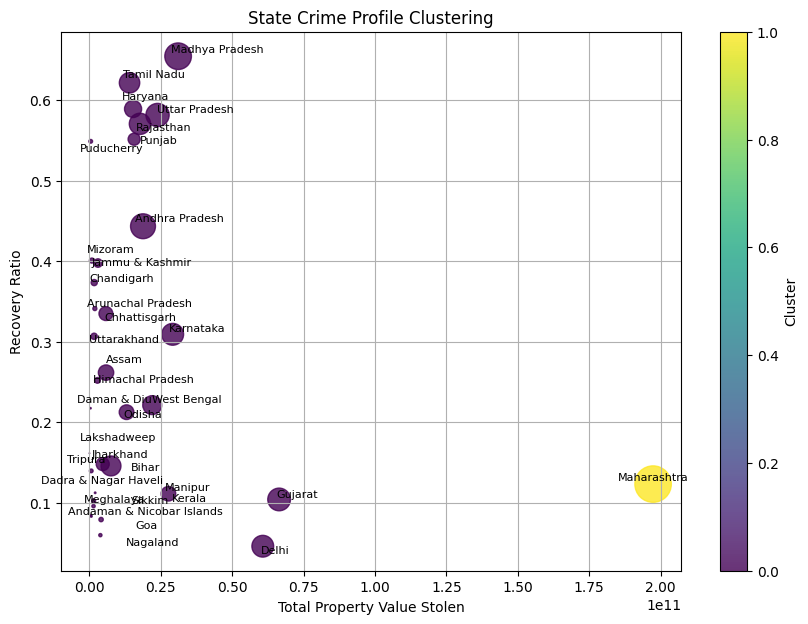

In [ ]:
from adjustText import adjust_text

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    df_state["Value_of_Property_Stolen"],
    df_state["Recovery_Ratio"],
    c=df_state["Cluster"],
    cmap="viridis",
    s=df_state["Cases_Property_Stolen"]/2000,
    alpha=0.8
)

texts = []

for i, row in df_state.iterrows():
    texts.append(
        plt.text(
            row["Value_of_Property_Stolen"],
            row["Recovery_Ratio"],
            row["Area_Name"],
            fontsize=8
        )
    )

adjust_text(texts)

plt.xlabel("Total Property Value Stolen")
plt.ylabel("Recovery Ratio")
plt.title("State Crime Profile Clustering")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()
